In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

from network_original_lpn import LPN
from network_ne_by_norm import NE_LPN_By_Norm
from network_scale_equiv_by_design import Scale_LPN_By_Design
from utils import prox

sns.set()

MODEL_DIR = "experiments/models/"
PLOT_DIR = "experiments/plots/"
os.makedirs(PLOT_DIR, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
class NormalSampler:
    def __init__(self, mean=0.0, std=1.0):
        self.mean = mean
        self.std = std

    def __call__(self, n):
        return torch.randn(n) * self.std + self.mean

def add_noise(x, sigma=0.1):
    return x + torch.randn_like(x) * sigma

In [3]:
class SplitNormalSampler:
    def __init__(self, mean: float = 0.0, std_left: float = 1.0, std_right: float = 2.0):
        self.mean = mean
        self.std_left = std_left
        self.std_right = std_right
        self.p_left = std_left / (std_left + std_right)

    def __call__(self, n: int):
        u = torch.rand(n)
        z = torch.randn(n).abs()
        samples = torch.where(
            u < self.p_left,
            self.mean - z * self.std_left,
            self.mean + z * self.std_right
        )
        return samples

In [4]:
def test_model(model, model_name, sampler, sigma_noise=1.0):
    model.eval()
    model = model.to(device)
    
    with torch.no_grad():
        test_clean = sampler(10000).unsqueeze(1).to(device)
        test_noisy = add_noise(test_clean, sigma_noise).to(device)
        test_denoised = model(test_noisy)

        mse = torch.nn.functional.mse_loss(test_denoised, test_clean).item()

        plt.figure(figsize=(3, 3))
        plt.scatter(test_noisy.cpu(), test_clean.cpu(), label="clean target", s=4, alpha=0.5)
        plt.scatter(test_noisy.cpu(), test_denoised.cpu(), label="denoised", s=4, alpha=0.5)
        plt.plot([-4, 4], [-4, 4], 'k--', lw=1)
        plt.legend()
        plt.title(f"{model_name} | MSE: {mse:.4f}")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, f"{model_name}_test_scatter.png"))
        plt.show()

        return mse

In [ ]:
mean, std_left, std_right = 0.0, 1.0, 2.0
sampler = SplitNormalSampler(mean=mean, std_left=std_left, std_right=std_right) 
sigma_noise = 0.1

dim = 1
hidden = 50
layers = 4
beta = 10

In [6]:
model_defs = {
    "Original LPN": LPN,
    "Equivariant by Design": NE_LPN_By_Norm,
    "Equivariant by Normalization Trick": Scale_LPN_By_Design
}

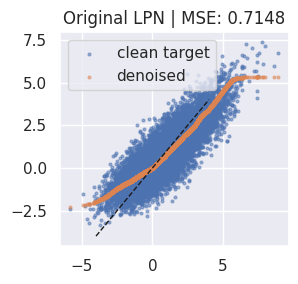

RuntimeError: Error(s) in loading state_dict for NE_LPN_By_Norm:
	Missing key(s) in state_dict: "res.0.bias", "res.1.bias", "res.2.bias", "res.3.bias". 

In [7]:
results = {}
for name, cls in model_defs.items():
    model = cls(in_dim=dim, hidden=hidden, layers=layers, beta=beta)
    model.load_state_dict(torch.load(os.path.join(MODEL_DIR, f"{name}.pth"), map_location=device))
    mse = test_model(model, name, sampler, sigma_noise=sigma_noise)
    results[name] = mse

print("\nFinal Test MSEs:")
for name, mse in results.items():
    print(f"{name}: {mse:.6f}")